In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
df = pd.read_csv('Dataset.csv')

In [118]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [119]:
df.shape

(7043, 21)

In [120]:
df = df.drop(['customerID'], axis=1)

In [121]:
df = df.drop(['SeniorCitizen', 'PhoneService', 'MultipleLines', 'PaperlessBilling'], axis=1)

In [122]:
df.shape

(7043, 16)

In [123]:
df.isnull().sum()

gender              0
Partner             0
Dependents          0
tenure              0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [124]:
cols = ['Partner', 'Dependents', 'OnlineSecurity', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'OnlineBackup', 'Churn']
df[cols] = df[cols].apply(lambda x : x.map({'Yes': 1, 'No': 0, 'No internet service': 0}))

In [133]:
df.sample(5)

,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2264,0,0,70,Fiber optic,1,1,1,1,1,1,114.95,7711.25,0,1,0,1,0,0,0
3512,0,0,51,No,0,0,0,0,0,0,25.00,1260.7,0,1,1,0,0,0,0
4453,1,0,10,Fiber optic,0,0,1,0,1,1,98.50,1037.75,1,1,0,0,0,1,0
6010,1,1,24,No,0,0,0,0,0,0,24.20,609.05,0,1,0,1,0,0,1
3149,0,0,8,DSL,0,0,1,1,0,1,64.10,504.05,0,0,0,0,0,0,1


In [126]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [127]:
df = pd.get_dummies(df, columns = ['gender', 'Contract', 'PaymentMethod'], drop_first = True)

In [128]:
df.head(4)

,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,DSL,0,1,0,0,0,0,29.85,29.85,0,False,False,False,False,True,False
1,0,0,34,DSL,1,0,1,0,0,0,56.95,1889.5,0,True,True,False,False,False,True
2,0,0,2,DSL,1,1,0,0,0,0,53.85,108.15,1,True,False,False,False,False,True
3,0,0,45,DSL,1,0,1,1,0,0,42.30,1840.75,0,True,True,False,False,False,False


In [129]:
df = df.replace({True:1, False:0})

C:\Users\DELL\AppData\Local\Temp\ipykernel_2864\1542668848.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True:1, False:0})


In [135]:
df['InternetService'] = df['InternetService'].map({'DSL': 1, 'Fiber optic': 1, 'No': 0})

In [136]:
df.head(5)

,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,0,1,0,0,0,0,29.85,29.85,0,0,0,0,0,1,0
1,0,0,34,1,1,0,1,0,0,0,56.95,1889.5,0,1,1,0,0,0,1
2,0,0,2,1,1,1,0,0,0,0,53.85,108.15,1,1,0,0,0,0,1
3,0,0,45,1,1,0,1,1,0,0,42.30,1840.75,0,1,1,0,0,0,0
4,0,0,2,1,0,0,0,0,0,0,70.70,151.65,1,0,0,0,0,1,0


In [137]:
df.isnull().sum()

Partner                                  0
Dependents                               0
tenure                                   0
InternetService                          0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
dtype: int64

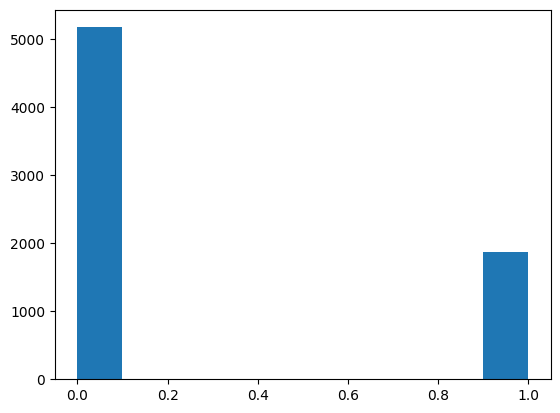

In [138]:
plt.hist(df['Churn'])
plt.show()

<Axes: >

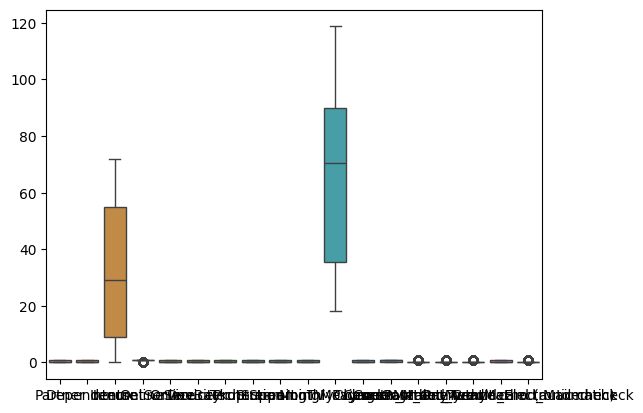

In [139]:
import seaborn as sns
sns.boxplot(data=df)

In [140]:
df.describe()

,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,Churn,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.483033,0.299588,32.371149,0.783331,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,64.761692,0.265370,0.504756,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.499748,0.458110,24.559481,0.412004,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,30.090047,0.441561,0.500013,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.350000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [146]:
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [147]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print(outliers)

Partner                                     0
Dependents                                  0
tenure                                      0
InternetService                          1526
OnlineSecurity                              0
OnlineBackup                                0
DeviceProtection                            0
TechSupport                                 0
StreamingTV                                 0
StreamingMovies                             0
MonthlyCharges                              0
TotalCharges                                0
Churn                                       0
gender_Male                                 0
Contract_One year                        1473
Contract_Two year                        1695
PaymentMethod_Credit card (automatic)    1522
PaymentMethod_Electronic check              0
PaymentMethod_Mailed check               1612
dtype: int64


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Partner                                7043 non-null   int64  
 1   Dependents                             7043 non-null   int64  
 2   tenure                                 7043 non-null   int64  
 3   InternetService                        7043 non-null   int64  
 4   OnlineSecurity                         7043 non-null   int64  
 5   OnlineBackup                           7043 non-null   int64  
 6   DeviceProtection                       7043 non-null   int64  
 7   TechSupport                            7043 non-null   int64  
 8   StreamingTV                            7043 non-null   int64  
 9   StreamingMovies                        7043 non-null   int64  
 10  MonthlyCharges                         7043 non-null   float64
 11  Tota

In [148]:
# Remove rows where all these columns are zero
cols_to_check = ['Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df = df[~(df[cols_to_check] == 0).all(axis=1)]

In [149]:
# Remove rows with TotalCharges = 0 (new customers with no history)
df = df[df['TotalCharges'] != 0]

In [150]:
df = df.reset_index(drop=True)

In [151]:
df.isnull().sum()

Partner                                   0
Dependents                                0
tenure                                    0
InternetService                           0
OnlineSecurity                            0
OnlineBackup                              0
DeviceProtection                          0
TechSupport                               0
StreamingTV                               0
StreamingMovies                           0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
gender_Male                               0
Contract_One year                         0
Contract_Two year                         0
PaymentMethod_Credit card (automatic)     0
PaymentMethod_Electronic check            0
PaymentMethod_Mailed check                0
dtype: int64

In [152]:
df.shape

(5900, 19)

In [153]:
# Fill missing TotalCharges with tenure * MonthlyCharges
df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

In [154]:
df.head(3)

,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,0,1,0,0,0,0,29.85,29.85,0,0,0,0,0,1,0
1,0,0,34,1,1,0,1,0,0,0,56.95,1889.50,0,1,1,0,0,0,1
2,0,0,2,1,1,1,0,0,0,0,53.85,108.15,1,1,0,0,0,0,1


<Axes: >

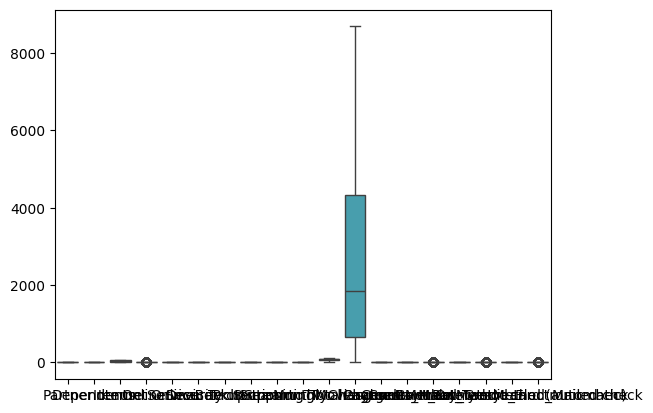

In [155]:
sns.boxplot(data=df)

In [156]:
# Cap outliers at 99th percentile for numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper_limit)

<Axes: >

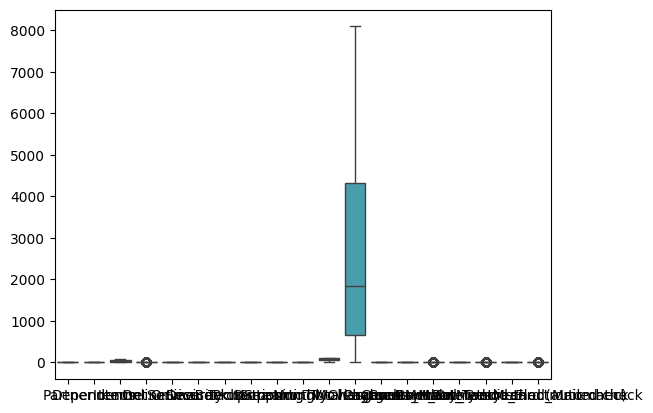

In [157]:
sns.boxplot(data=df)

In [158]:
# Check actual outlier counts
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

# If still showing, remove outliers completely
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5900 entries, 0 to 5899
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Partner                                5900 non-null   int64  
 1   Dependents                             5900 non-null   int64  
 2   tenure                                 5900 non-null   int64  
 3   InternetService                        5900 non-null   int64  
 4   OnlineSecurity                         5900 non-null   int64  
 5   OnlineBackup                           5900 non-null   int64  
 6   DeviceProtection                       5900 non-null   int64  
 7   TechSupport                            5900 non-null   int64  
 8   StreamingTV                            5900 non-null   int64  
 9   StreamingMovies                        5900 non-null   int64  
 10  MonthlyCharges                         5900 non-null   float64
 11  Tota

In [160]:
df.describe()

,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000,5900.000000
mean,0.576610,0.357627,35.532373,0.855085,0.342203,0.411695,0.410508,0.346441,0.458814,0.463051,70.246483,2627.611411,0.260000,0.500169,0.221864,0.256780,0.227458,0.351186,0.188475
std,0.494138,0.479342,24.195924,0.352045,0.474488,0.492182,0.491968,0.475876,0.498343,0.498675,28.321578,2298.159834,0.438671,0.500042,0.415536,0.436894,0.419226,0.477382,0.391124
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,12.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.300000,663.025000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,34.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,76.400000,1852.150000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,58.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,93.662500,4319.475000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,115.100000,8100.253000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


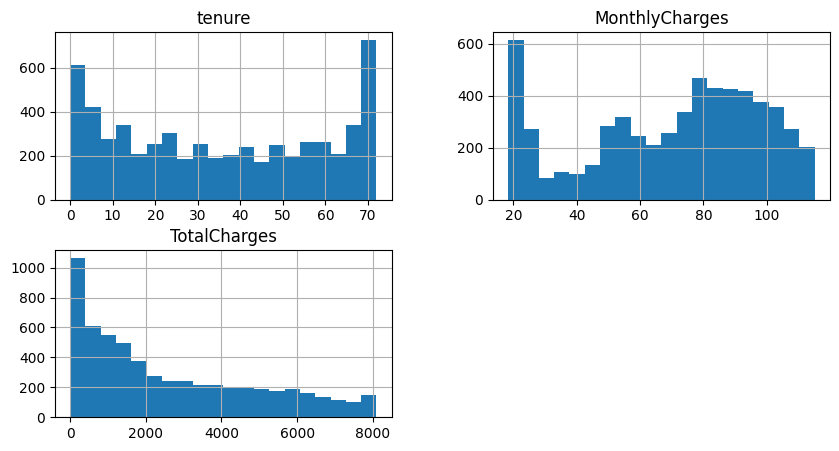

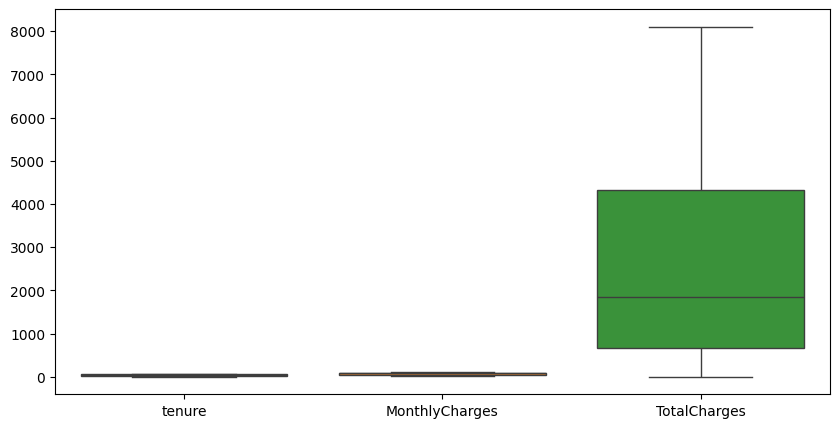

In [161]:
# Histograms
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=20, figsize=(10,5))
plt.show()

# Boxplots to check outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['tenure', 'MonthlyCharges', 'TotalCharges']])
plt.show()


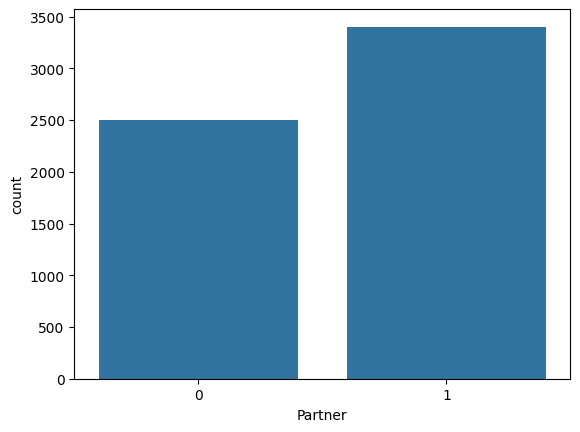

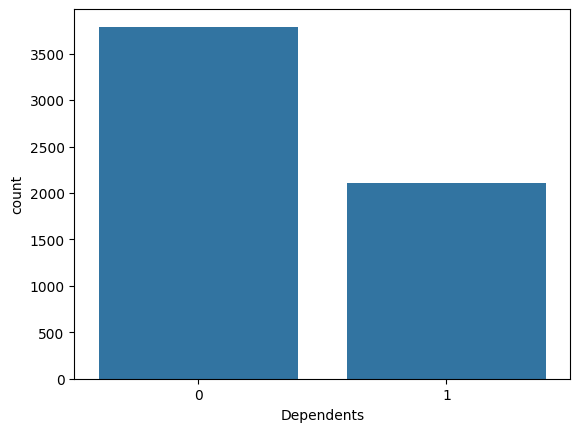

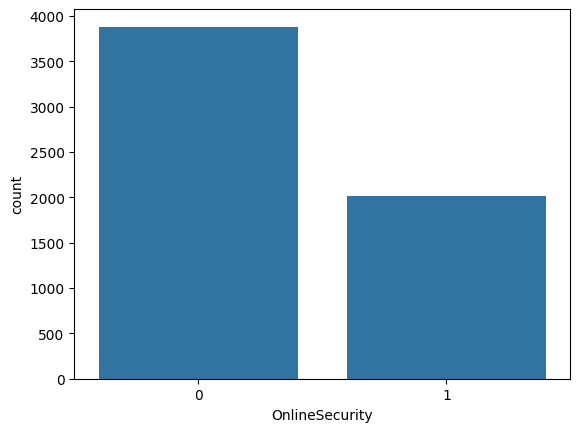

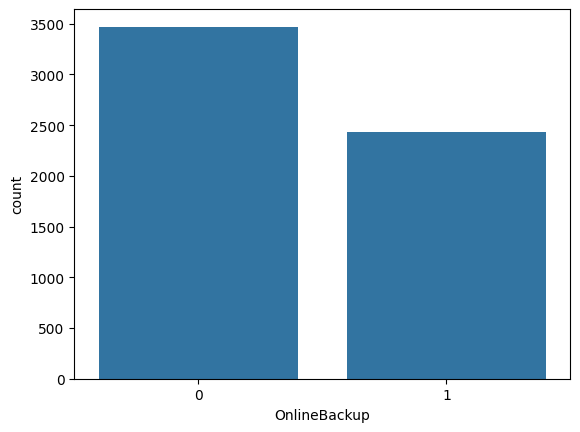

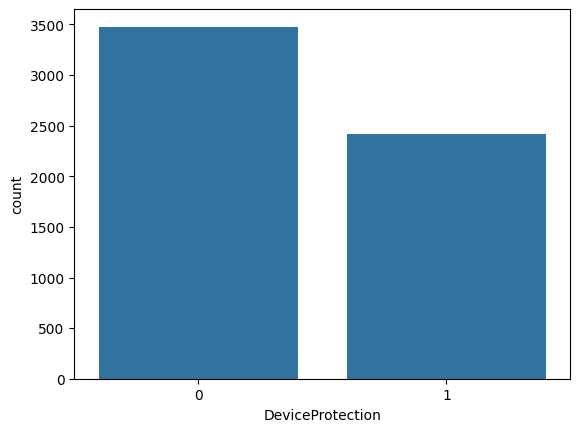

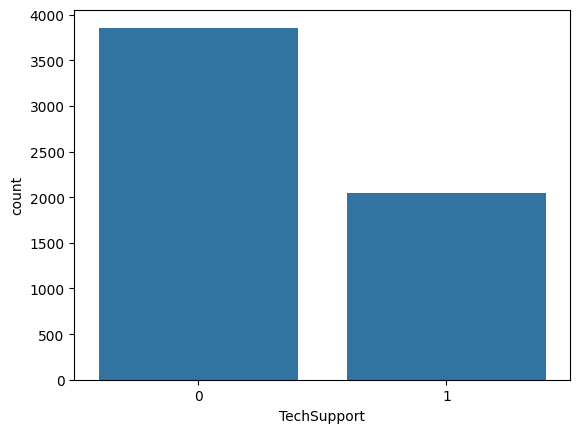

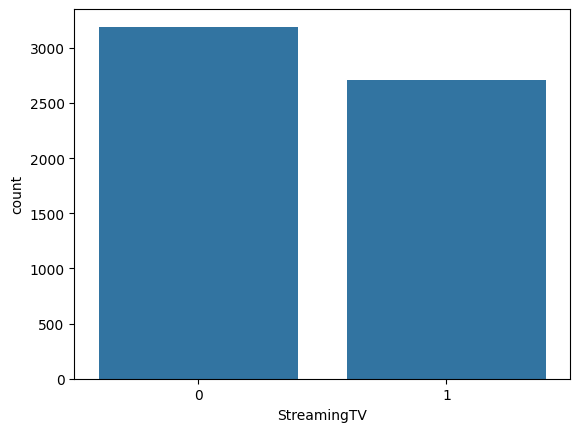

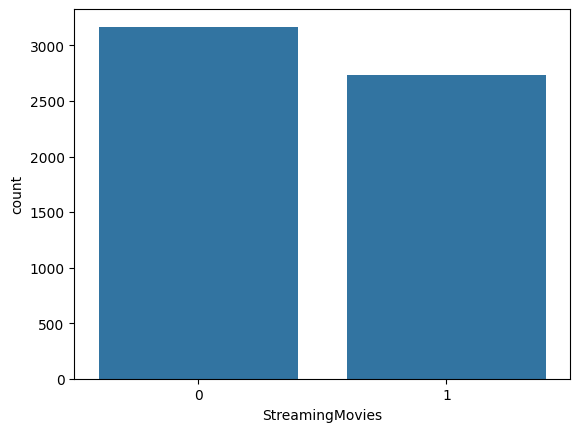

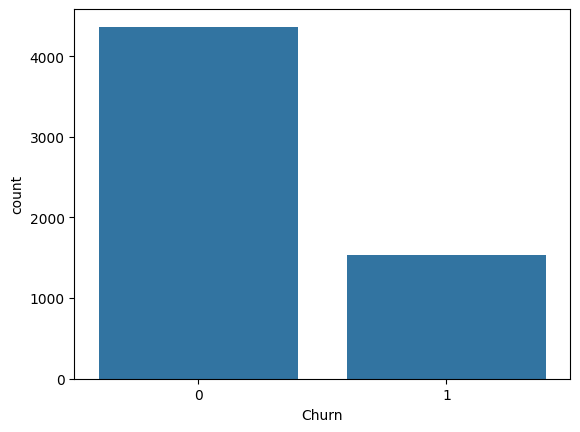

In [162]:
# Count plots
binary_cols = ['Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Churn']

for col in binary_cols:
    sns.countplot(x=col, data=df)
    plt.show()


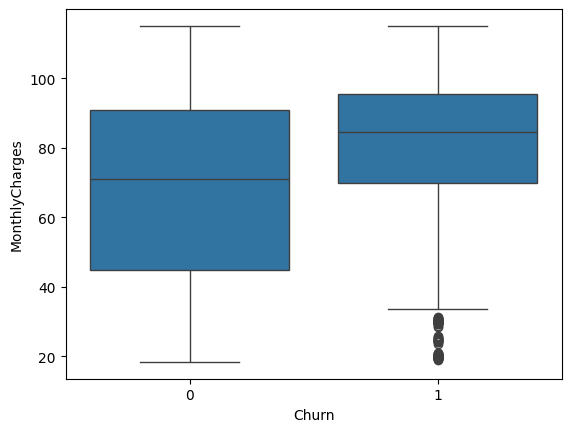

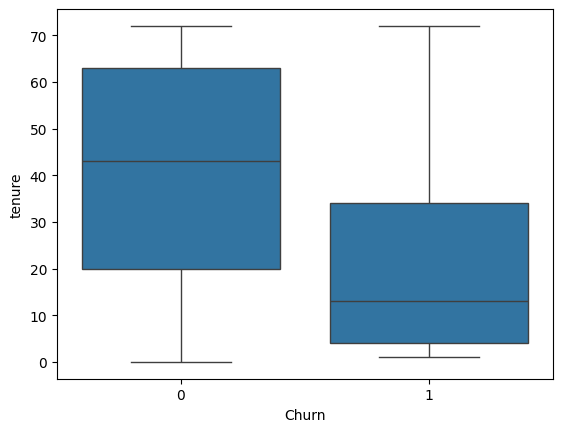

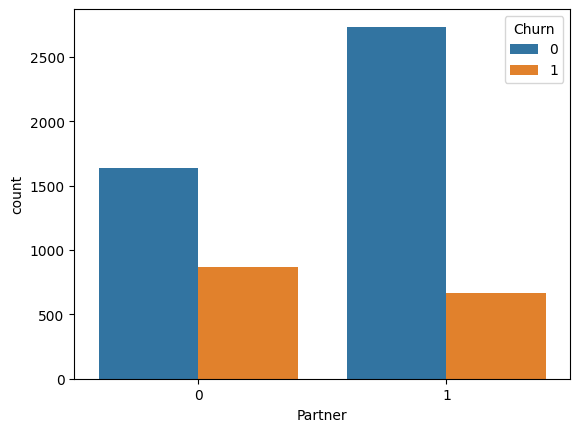

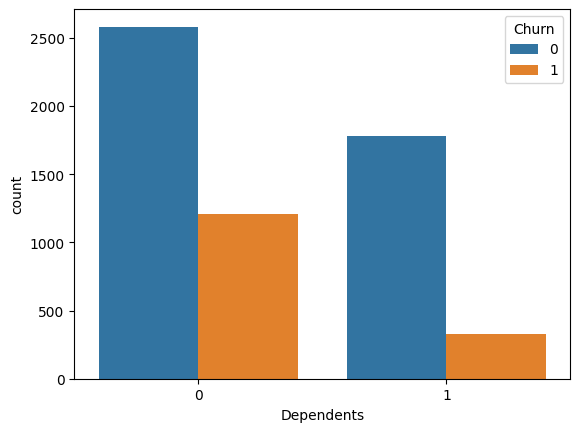

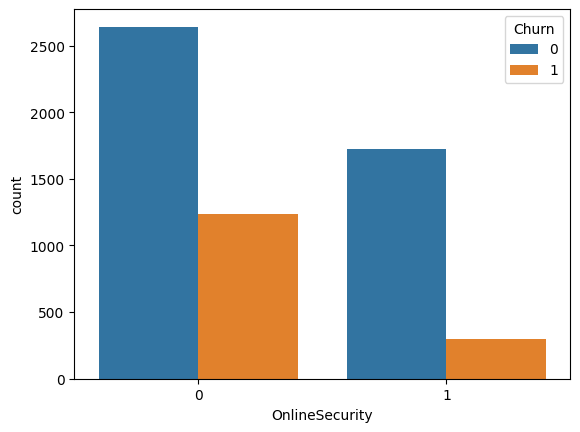

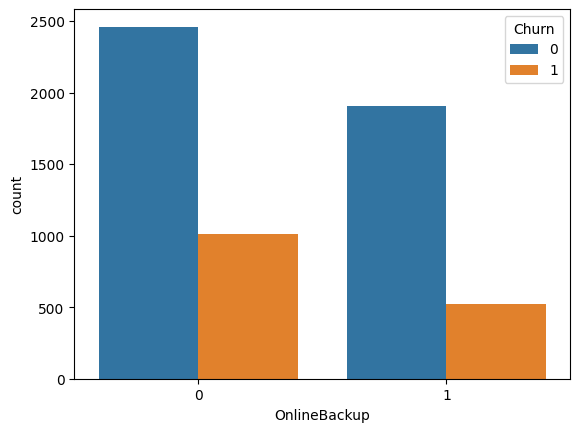

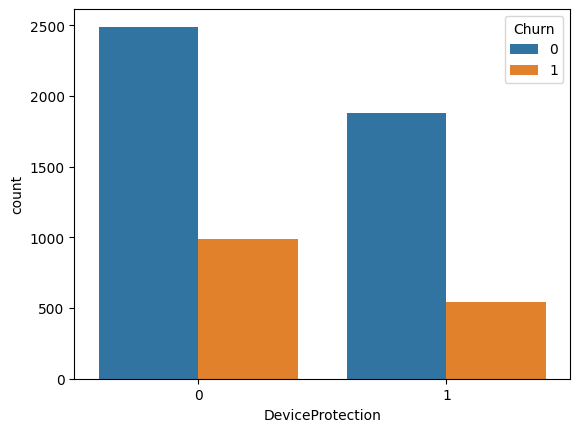

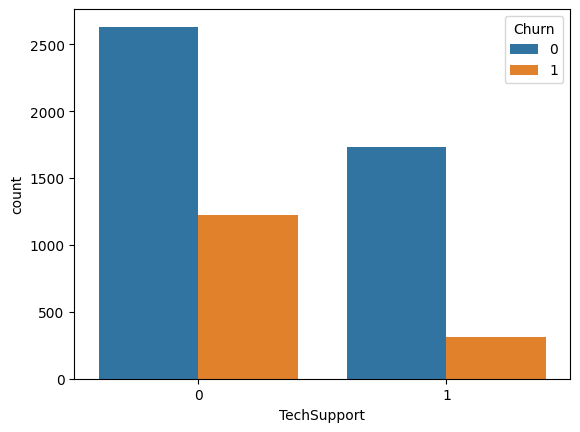

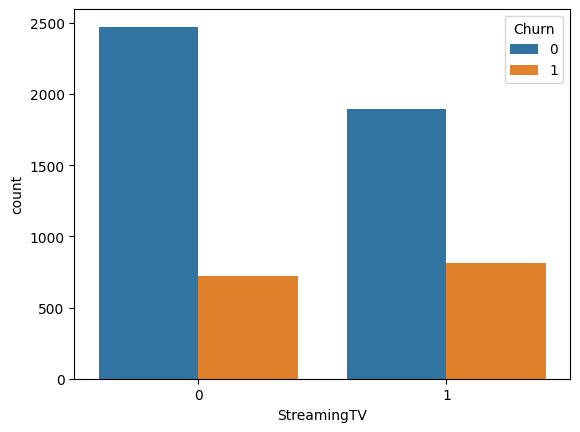

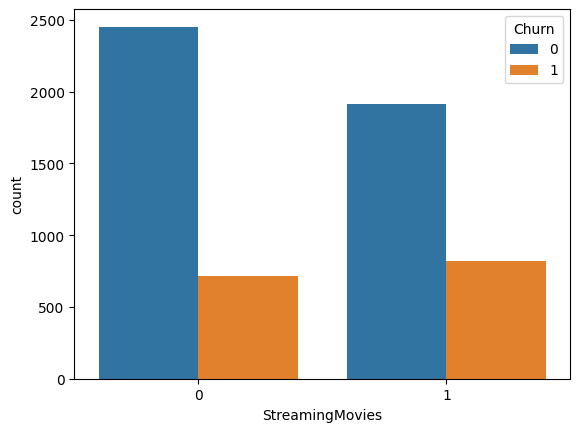

In [107]:
# For numerical columns
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

# For categorical columns
for col in binary_cols:
    if col != 'Churn':
        sns.countplot(x=col, hue='Churn', data=df)
        plt.show()


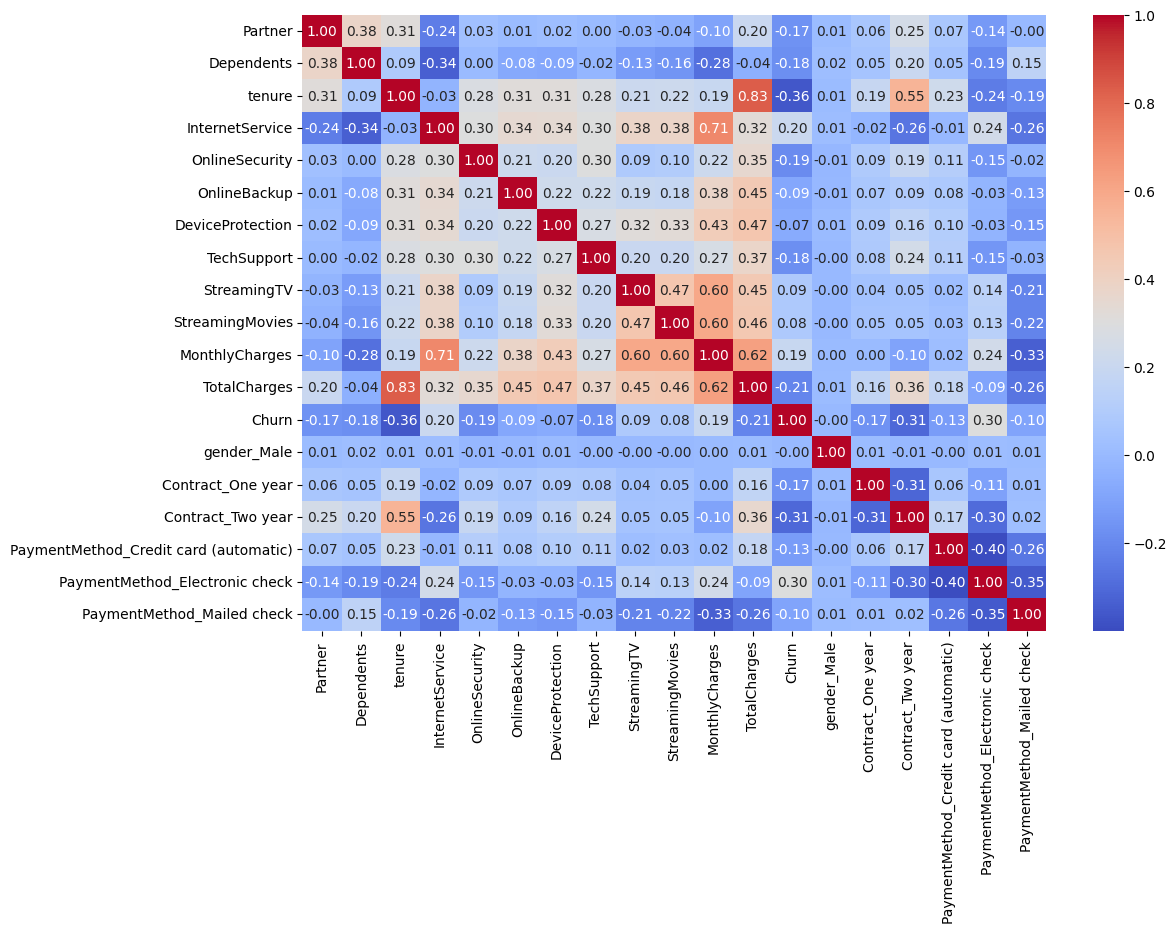

In [163]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()


In [164]:
df.sample(4)

,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3960,1,0,24,1,1,0,0,0,0,1,39.10,971.30,1,1,0,0,0,0,0
4468,1,1,49,1,0,1,1,1,1,1,107.95,5293.20,1,0,0,1,0,0,0
591,1,1,47,1,0,1,0,0,1,0,84.95,4018.05,0,1,1,0,0,0,0
636,0,0,27,1,1,1,0,0,0,0,56.70,1652.95,0,0,0,0,0,0,1


In [165]:
df['tenure_group'] = pd.cut(df['tenure'],
                           bins = [0, 12, 24, 48, 100], 
                           labels = ['0-1 year', '1-2 years', '2-4 years', '4+ years'])

In [166]:
df.sample(5)

,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group
1895,1,1,44,0,0,0,0,0,0,0,24.85,1013.60,0,1,1,0,0,1,0,2-4 years
4300,1,1,55,0,0,0,0,0,0,0,25.65,1388.00,0,0,0,1,1,0,0,4+ years
2400,0,0,11,1,0,1,1,1,0,1,94.20,999.90,0,0,0,0,0,1,0,0-1 year
4582,1,0,71,1,0,1,1,0,0,1,89.45,6435.25,0,0,0,1,1,0,0,4+ years
339,0,0,34,1,0,1,0,0,0,0,73.95,2524.45,1,0,0,0,1,0,0,2-4 years


In [167]:
services_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'InternetService']
df['total_services'] = df[services_cols].sum(axis = 1)

In [170]:
df.sample(1)

,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,...,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,total_services
867,0,0,5,1,0,1,0,0,1,0,...,392.5,0,0,0,0,0,1,0,0-1 year,3


In [171]:
from sklearn.preprocessing import StandardScaler

In [172]:
scaler = StandardScaler()

In [173]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [174]:
from sklearn.model_selection import train_test_split

x = df.drop('Churn', axis = 1)
y = df['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [178]:
x_train['tenure_group'] = x_train['tenure_group'].astype('category').cat.codes
x_test['tenure_group'] = x_test['tenure_group'].astype('category').cat.codes

model = LogisticRegression(max_iter = 1000)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8203389830508474
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       873
           1       0.69      0.55      0.62       307

    accuracy                           0.82      1180
   macro avg       0.77      0.73      0.75      1180
weighted avg       0.81      0.82      0.81      1180



In [179]:
from sklearn.ensemble import RandomForestClassifier

In [182]:
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.8042372881355933
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       873
           1       0.66      0.50      0.57       307

    accuracy                           0.80      1180
   macro avg       0.75      0.71      0.72      1180
weighted avg       0.79      0.80      0.79      1180



In [183]:
importances = pd.DataFrame({
    'feature' : x_train.columns, 
    'importance' : rf.feature_importances_
}).sort_values('importance', ascending = False)
print(importances.head(10))

                           feature  importance
10                  MonthlyCharges    0.198825
11                    TotalCharges    0.182604
2                           tenure    0.159552
19                  total_services    0.055509
18                    tenure_group    0.053890
16  PaymentMethod_Electronic check    0.041612
14               Contract_Two year    0.034562
12                     gender_Male    0.029642
0                          Partner    0.026353
13               Contract_One year    0.026232


In [190]:
from xgboost import XGBClassifier

In [192]:
xgb = XGBClassifier(n_estimators = 100, learning_rate = 0.1, random_state = 42)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

print(accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

0.8152542372881356
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       873
           1       0.68      0.54      0.61       307

    accuracy                           0.82      1180
   macro avg       0.77      0.73      0.74      1180
weighted avg       0.81      0.82      0.81      1180



In [189]:
print('Hello')

Hello


In [194]:
rf_balanced = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42)
rf_balanced.fit(x_train, y_train)
y_pred_rf_balanced = rf_balanced.predict(x_test)

print(accuracy_score(y_test, y_pred_rf_balanced))
print(classification_report(y_test, y_pred_rf_balanced))

0.8050847457627118
              precision    recall  f1-score   support

           0       0.83      0.92      0.88       873
           1       0.68      0.47      0.56       307

    accuracy                           0.81      1180
   macro avg       0.76      0.70      0.72      1180
weighted avg       0.79      0.81      0.79      1180



In [198]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Retrain Logistic Regression on resampled data
model.fit(x_train_resampled, y_train_resampled)
y_pred_smote = model.predict(x_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       873
           1       0.52      0.71      0.60       307

    accuracy                           0.76      1180
   macro avg       0.70      0.74      0.71      1180
weighted avg       0.79      0.76      0.77      1180



In [196]:
!pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]



In [199]:
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced')
model_weighted.fit(x_train, y_train)
y_pred_weighted = model_weighted.predict(x_test)

print(accuracy_score(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))

0.735593220338983
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       873
           1       0.49      0.79      0.61       307

    accuracy                           0.74      1180
   macro avg       0.70      0.75      0.70      1180
weighted avg       0.80      0.74      0.75      1180



In [200]:
y_probs = model.predict_proba(x_test)[:, 1]
threshold = 0.4
y_pred_custom = (y_probs >=threshold).astype(int)
print(f"THreshold : {threshold}")
print(classification_report(y_test, y_pred_custom))

THreshold : 0.4
              precision    recall  f1-score   support

           0       0.90      0.71      0.79       873
           1       0.49      0.77      0.60       307

    accuracy                           0.73      1180
   macro avg       0.69      0.74      0.70      1180
weighted avg       0.79      0.73      0.74      1180



In [201]:
y_probs = model.predict_proba(x_test)[:, 1]
threshold = 0.3
y_pred_custom = (y_probs >=threshold).astype(int)
print(f"THreshold : {threshold}")
print(classification_report(y_test, y_pred_custom))

THreshold : 0.3
              precision    recall  f1-score   support

           0       0.92      0.65      0.76       873
           1       0.46      0.84      0.59       307

    accuracy                           0.70      1180
   macro avg       0.69      0.74      0.68      1180
weighted avg       0.80      0.70      0.72      1180



In [202]:
y_probs = model.predict_proba(x_test)[:, 1]
threshold = 0.45
y_pred_custom = (y_probs >=threshold).astype(int)
print(f"THreshold : {threshold}")
print(classification_report(y_test, y_pred_custom))

THreshold : 0.45
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       873
           1       0.50      0.74      0.60       307

    accuracy                           0.74      1180
   macro avg       0.70      0.74      0.70      1180
weighted avg       0.79      0.74      0.75      1180



In [204]:
# Convert tenure_group to numeric
df['tenure_group'] = df['tenure_group'].astype('category').cat.codes

# Now run clustering code again
cluster_features = ['tenure', 'MonthlyCharges', 'total_services', 'tenure_group']
X_cluster = df[cluster_features]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

In [205]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
cluster_features = ['tenure', 'MonthlyCharges', 'total_services', 'tenure_group']
X_cluster = df[cluster_features]

# Scale
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Find optimal clusters (Elbow method)
inertia = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

# Choose k (usually 3-5) and fit final model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_cluster_scaled)

# Analyze segments
print(df.groupby('segment')[cluster_features].mean())

           tenure  MonthlyCharges  total_services  tenure_group
segment                                                        
0        1.129502        0.646579        0.897497      2.974591
1       -1.152517       -0.288368       -0.496683      0.186008
2       -0.199197        0.472352        0.349729      1.692570
3        0.426895       -1.531570       -1.403011      2.310105


segment
0    0.120271
1    0.461410
2    0.308793
3    0.042973
Name: Churn, dtype: float64


<Axes: xlabel='segment'>

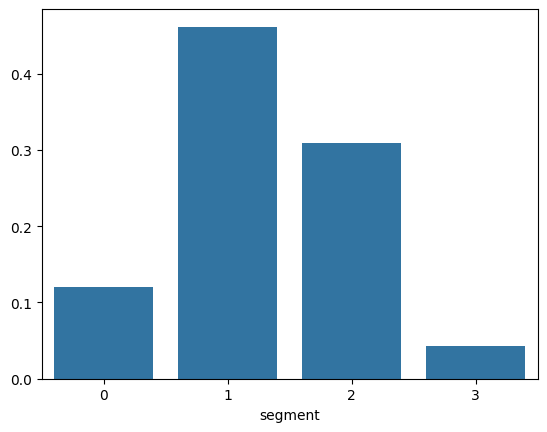

In [206]:
# Add churn rate analysis
df['segment'] = kmeans.labels_
segment_churn = df.groupby('segment')['Churn'].mean()
print(segment_churn)

# Visualize
import seaborn as sns
sns.barplot(x=segment_churn.index, y=segment_churn.values)

In [207]:
# Simple CLV formula
df['CLV'] = df['MonthlyCharges'] * df['tenure']  # Adjust as needed

# CLV by segment
segment_clv = df.groupby('segment')['CLV'].mean()
print(segment_clv)

# Combine churn and CLV insights
segment_summary = df.groupby('segment').agg({
    'Churn': 'mean',
    'CLV': 'mean',
    'MonthlyCharges': 'mean',
    'tenure': 'mean'
}).round(2)
print(segment_summary)


segment
0    0.743518
1    0.328636
2   -0.140588
3   -0.647901
Name: CLV, dtype: float64
         Churn   CLV  MonthlyCharges  tenure
segment                                     
0         0.12  0.74            0.65    1.13
1         0.46  0.33           -0.29   -1.15
2         0.31 -0.14            0.47   -0.20
3         0.04 -0.65           -1.53    0.43


In [209]:
# Add this AFTER your model training
import joblib

joblib.dump(model, 'churn_model.pkl')  # Your best Logistic Regression model
joblib.dump(kmeans, 'kmeans_model.pkl')  # Your K-Means model
joblib.dump(scaler, 'scaler.pkl')  # Your scaler
joblib.dump(x_train.columns.tolist(), 'training_columns.pkl')  # Column names

['training_columns.pkl']